# Horse racing data analysis

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm

file_name = 'horse_racing_data.csv'
processed_data = 'horse_racing_data(preprocessing).csv'
current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'horse racing data' + '\\' 
image_path = current_path + '\\' + 'image' + '\\' + 'horse racing' + '\\' 

name_columns = 'Horse'
covariate_columns = ['Act. Wt.','Dr.','Win Odds']

### Data preprocessing

Drop Nan

In [2]:
df = pd.read_csv(data_path + file_name,index_col='race_id')
#covariate_columns = ['Act. Wt.','Declar. Horse Wt.','Dr.','Win Odds']
covariate_columns = ['Act. Wt.','Dr.','Win Odds']
NaN_columns = covariate_columns+['Pla.']
for covariate in NaN_columns:
    df[covariate] = pd.to_numeric(df[covariate], errors='coerce')
    df = df.dropna(subset=[covariate])


Select suitable matches and players

In [4]:
def delete_matches(df,m_lower=0,m_upper=100):
    df = df.copy()
    i = 0
    indexes = []
    for index in df.index.unique():
        m = df[df.index == index].shape[0]
        if m >= m_lower and m <= m_upper:
            i += 1
        else:
            indexes.append(index)
    df = df.drop(index = indexes)
    return df,i

def delete_players(df,d_min=0,name = 'Horse'):
    counts = df[name].value_counts()
    values_to_keep = counts[counts >= d_min].index
    df = df[df[name].isin(values_to_keep)]
    return df,len(values_to_keep)

def select(df,m_lower=0,m_upper=100,d_min=0,name = 'Horse'):
    NN = len(df.index.unique())
    nn = len(df[name].value_counts())
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of horses: {nn}')
        df,N = delete_matches(df,m_lower,m_upper)
        df,n = delete_players(df,d_min)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N

In [5]:
m_lower = 4
m_upper = 14
d_min = 25
df,n,N = select(df,m_lower,m_upper,d_min)

----------
The number of matches: 18644
The number of horses: 11256
----------
The number of matches: 18644
The number of horses: 3969
----------
The number of matches: 17915
The number of horses: 3872
----------
The number of matches: 17681
The number of horses: 3828
----------
The number of matches: 17521
The number of horses: 3800
----------
The number of matches: 17418
The number of horses: 3768
----------
The number of matches: 17277
The number of horses: 3740
----------
The number of matches: 17178
The number of horses: 3725
----------
The number of matches: 17124
The number of horses: 3717
----------
The number of matches: 17090
The number of horses: 3709
----------
The number of matches: 17059
The number of horses: 3701
----------
The number of matches: 17027
The number of horses: 3693
----------
The number of matches: 16998
The number of horses: 3689
----------
The number of matches: 16984
The number of horses: 3687
----------
The number of matches: 16974
The number of horses:

Normalization

In [6]:
# Actual Weight
df['Act. Wt.'] = np.log(df['Act. Wt.'])
mean_A = df['Act. Wt.'].mean()
std_A = df['Act. Wt.'].std()
df['Act. Wt.'] = (df['Act. Wt.'] - mean_A) / std_A
# Draw
df['Dr.']
for index in df.index.unique():
    df.loc[index,'Dr.'] = pd.Series(df.loc[index,'Dr.']/max(df.loc[index,'Dr.'])).astype(float)
# Belief
for index in df.index.unique():
    t = df.loc[index,'Win Odds']
    df.loc[index,'Win Odds'] = np.log((1 / t) / np.sum(1 / t))

In [7]:
df.to_csv(data_path+'horse_racing_data(preprocessing).csv')

### Data Analysis

Construct T and X

In [28]:
df = pd.read_csv(data_path + processed_data,index_col='race_id')

horseID = {}
T = []
X = []
for index in df.index.unique():
    x = np.array(df[covariate_columns].loc[index])
    X.append(x)

    t = []
    horses_name = df[name_columns].loc[index].tolist()
    for horse_name in horses_name:
        added_horse = horseID.keys()
        if horse_name in added_horse:
            pass
        else:
            n = len(added_horse)
            horseID[horse_name] = n
        t.append(horseID[horse_name])
    T.append(t)
n = len(horseID)

C:\Users\13299\AppData\Local\Temp\ipykernel_7692\3257070372.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path + processed_data,index_col='race_id')


PlusDC

In [ ]:
u_plusDC,v_plusDC = algorithm.AM(T,X,n,E=1e-8,Eu=1e-8,Ev=1e-12,I=50,detail=True)
l_plusDC = algorithm.multi_likelihood(T,X,n,u_plusDC,v_plusDC)
print(l_plusDC)

-----1-----
log-likelihood: -12.235750155257655
v iterative times: 6 and v = [-0.03670322 -0.10804421  0.58424042]
u iterative times: 50
-----2-----
log-likelihood: -11.15198903243214
v iterative times: 5 and v = [-0.10057597 -0.14205028  0.56538862]
u iterative times: 50
-----3-----
log-likelihood: -11.132821090564205
v iterative times: 5 and v = [-0.11881379 -0.15143035  0.55363594]
u iterative times: 50
-----4-----
log-likelihood: -11.13011696030641
v iterative times: 4 and v = [-0.12495819 -0.15585228  0.54770028]
u iterative times: 50
-----5-----
log-likelihood: -11.12958972811483
v iterative times: 4 and v = [-0.12735798 -0.15802087  0.54478535]
u iterative times: 50
-----6-----
log-likelihood: -11.129471479335393
v iterative times: 4 and v = [-0.1284014  -0.15908817  0.54335324]
u iterative times: 50
-----7-----
log-likelihood: -11.129443464153933
v iterative times: 4 and v = [-0.12888543 -0.15961519  0.54264686]
u iterative times: 50
-----8-----
log-likelihood: -11.129436678246

In [31]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
i = 0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value == index][0]
    print(f'top-{i}: horse name:{horse_name}, score:{uu}')

top-1: horse name:GOLDEN SIXTY (C238), score:2.891280992994604
top-2: horse name:EXULTANT (B101), score:2.8171322017813916
top-3: horse name:TOURBILLON DIAMOND (E054), score:2.4654232730238954
top-4: horse name:BEAUTY GENERATION (V380), score:2.32131564110783
top-5: horse name:SEASONS BLOOM (V410), score:2.253217886485242
top-6: horse name:GOLD-FUN (P045), score:2.1650793973963403
top-7: horse name:MILITARY ATTACK (N175), score:2.069258268865476
top-8: horse name:DUKE WAI (C188), score:2.0095747013576517
top-9: horse name:COLUMBUS COUNTY (C465), score:2.0072771814757013
top-10: horse name:BUTTERFIELD (C462), score:2.006170954069648


PL

In [33]:
u_pl,v_pl = algorithm.AM(T,X,n,P=True,detail=True)
l_pl = algorithm.multi_likelihood(T,X,u_pl,v_pl)
print(l_pl)

-11.682460589191065


In [34]:
i=0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value == index][0]
    print(f'top-{i}: horse name:{horse_name}, score(PlusDC):{uu},score(PL):{u_pl[index]}')

top-1: horse name:GOLDEN SIXTY (C238), score(PlusDC):2.891280992994604,score(PL):5.5022171177005985
top-2: horse name:EXULTANT (B101), score(PlusDC):2.8171322017813916,score(PL):4.626401185751201
top-3: horse name:TOURBILLON DIAMOND (E054), score(PlusDC):2.4654232730238954,score(PL):3.908470303675119
top-4: horse name:BEAUTY GENERATION (V380), score(PlusDC):2.32131564110783,score(PL):4.2365206725737075
top-5: horse name:SEASONS BLOOM (V410), score(PlusDC):2.253217886485242,score(PL):3.5775898976297738
top-6: horse name:GOLD-FUN (P045), score(PlusDC):2.1650793973963403,score(PL):3.6300672188049994
top-7: horse name:MILITARY ATTACK (N175), score(PlusDC):2.069258268865476,score(PL):2.890042007567022
top-8: horse name:DUKE WAI (C188), score(PlusDC):2.0095747013576517,score(PL):3.528209162002346
top-9: horse name:COLUMBUS COUNTY (C465), score(PlusDC):2.0072771814757013,score(PL):3.254583516264736
top-10: horse name:BUTTERFIELD (C462), score(PlusDC):2.006170954069648,score(PL):3.047509322230

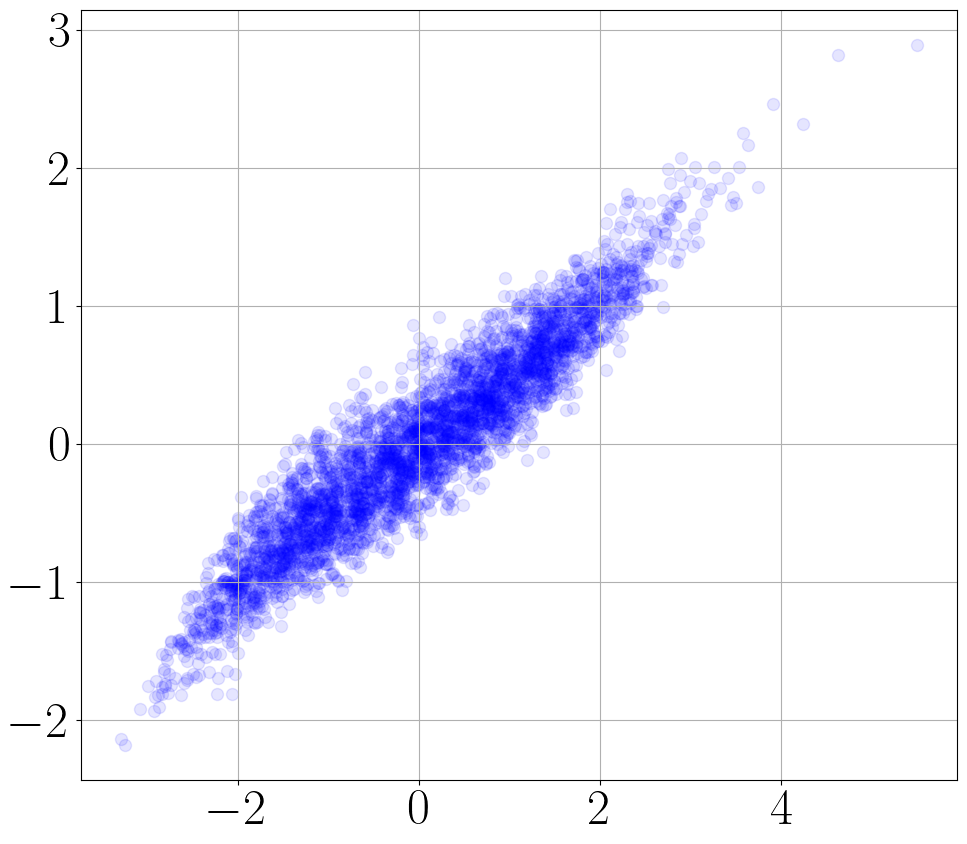

In [41]:
fig,ax = plt.subplots(figsize=(11.3,10))
ax.scatter(u_pl,u_plusDC,s = 75,alpha=0.1,c='blue')
sz = 36
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()

plt.savefig(image_path+'score.pdf')
plt.show()